In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)
x=np.random.rand(100,1)-0.5
y=3*x[:,0]**2 +0.05 * np.random.randn(100)

In [3]:
df=pd.DataFrame()

In [4]:
df['x']=x.reshape(100)
df['y']=y

In [5]:
df

,x,y
0,-0.125460,0.051573
1,0.450714,0.594480
2,0.231994,0.166052
3,0.098658,-0.070178
4,-0.343981,0.343986
...,...,...
95,-0.006204,-0.040675
96,0.022733,-0.002305
97,-0.072459,0.032809
98,-0.474581,0.689516


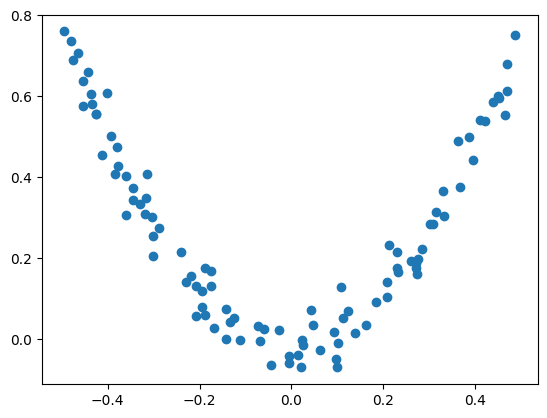

In [6]:
plt.scatter(x,y,)

In [7]:
df['pred1']=df['y'].mean()

In [8]:
df.head()

,x,y,pred1
0,-0.125460,0.051573,0.265458
1,0.450714,0.594480,0.265458
2,0.231994,0.166052,0.265458
3,0.098658,-0.070178,0.265458
4,-0.343981,0.343986,0.265458


In [9]:
df['res1']=df['y']-df['pred1']

In [10]:
df.head()

,x,y,pred1,res1
0,-0.125460,0.051573,0.265458,-0.213885
1,0.450714,0.594480,0.265458,0.329021
2,0.231994,0.166052,0.265458,-0.099407
3,0.098658,-0.070178,0.265458,-0.335636
4,-0.343981,0.343986,0.265458,0.078528


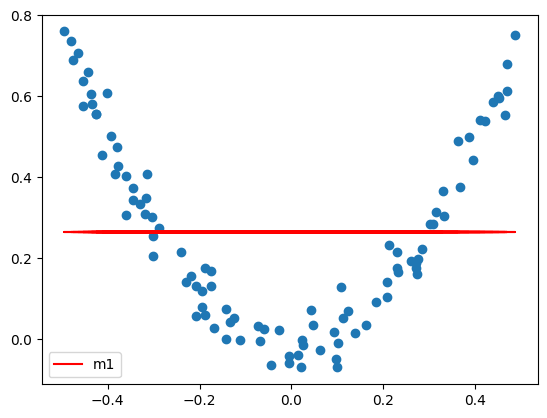

In [16]:
plt.scatter(df['x'],df['y'])
plt.plot(df['x'],df['pred1'],'r',label='m1')
plt.legend()

In [17]:
from sklearn.tree import DecisionTreeRegressor

In [18]:
tree1=DecisionTreeRegressor(max_leaf_nodes=8)

In [19]:
tree1.fit(df['x'].values.reshape(100,1),df['res1'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

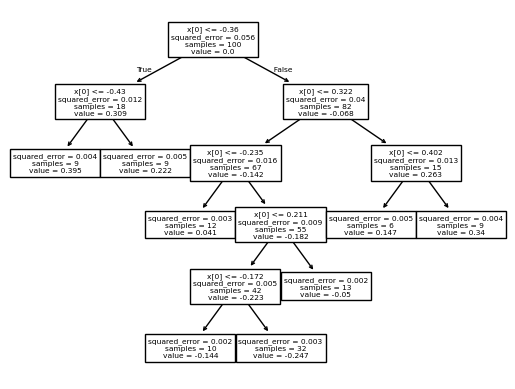

In [20]:
from sklearn.tree import *
plot_tree(tree1)
plt.show()

In [21]:
#generating x_test
x_test=np.linspace(-0.5,0.5,500)

In [22]:
y_pred=0.265458 * tree1.predict(x_test.reshape(500,1))

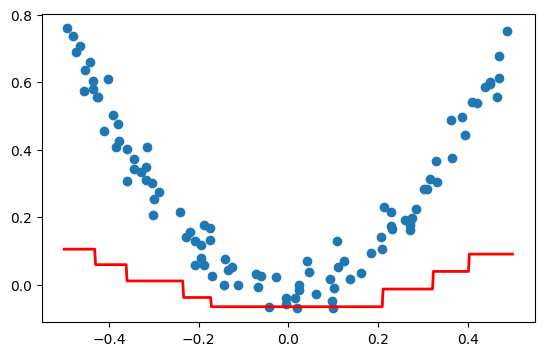

In [31]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.plot(x_test,y_pred,linewidth=2,color='r')
plt.scatter(df['x'],df['y'])
plt.show()

In [34]:
df['pred2']=0.26458 + tree1.predict(df['x'].values.reshape(100,1))
df.head()

,x,y,pred1,res1,pred2
0,-0.125460,0.051573,0.265458,-0.213885,0.017441
1,0.450714,0.594480,0.265458,0.329021,0.605006
2,0.231994,0.166052,0.265458,-0.099407,0.214906
3,0.098658,-0.070178,0.265458,-0.335636,0.017441
4,-0.343981,0.343986,0.265458,0.078528,0.305086


In [36]:
df['res2']=df['y']-df['pred2']
df

,x,y,pred1,res1,pred2,res2
0,-0.125460,0.051573,0.265458,-0.213885,0.017441,0.034132
1,0.450714,0.594480,0.265458,0.329021,0.605006,-0.010526
2,0.231994,0.166052,0.265458,-0.099407,0.214906,-0.048854
3,0.098658,-0.070178,0.265458,-0.335636,0.017441,-0.087619
4,-0.343981,0.343986,0.265458,0.078528,0.305086,0.038900
...,...,...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133,0.017441,-0.058116
96,0.022733,-0.002305,0.265458,-0.267763,0.017441,-0.019746
97,-0.072459,0.032809,0.265458,-0.232650,0.017441,0.015367
98,-0.474581,0.689516,0.265458,0.424057,0.660034,0.029482


In [37]:
tree2=DecisionTreeRegressor(max_leaf_nodes=8)

In [38]:
tree2.fit(df['x'].values.reshape(100,1),df['res2'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

In [39]:
y_pred=0.265458+ sum(regressor.predict(x_test.reshape(-1,1)) for regressor in [tree1,tree2])

Text(0.5, 1.0, 'x vs y')

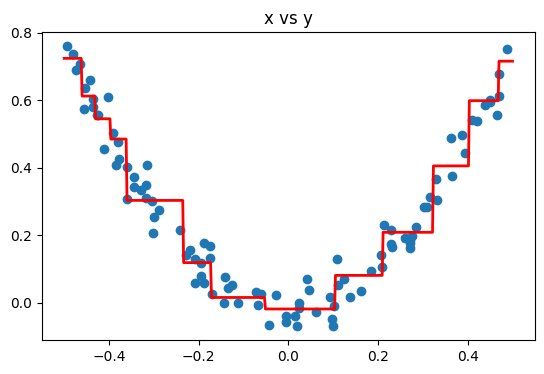

In [40]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.plot(x_test,y_pred,linewidth=2,color='r')
plt.scatter(df['x'],df['y'])
plt.title('x vs y')

In [61]:
def gradient_boost(x,y,number,lr,count=1,regs=[],foo=None):
    
    if number==0:
        return
    else:
        # do gradient boosting
        
        if count>1:
            y=y-regs[-1].predict(x)
        else:
            foo=y
            
        tree_reg=DecisionTreeRegressor(max_depth=5,random_state=42)
        tree_reg.fit(x,y)
        
        regs.append(tree_reg)
        
        x1=np.linspace(-0.5,0.5,500)
        y_pred=sum(lr*regressor.predict(x1.reshape(-1,1)) for regressor in regs)
        
        print(number)
        plt.figure()
        plt.plot(x1,y_pred,linewidth=2,label='prediction')
        plt.scatter(x[:,0],foo,color='red',label='True Values')
        plt.legend()
        plt.show()
        
        gradient_boost(x,y,number-1,lr,count+1,regs=regs,foo=foo)

5


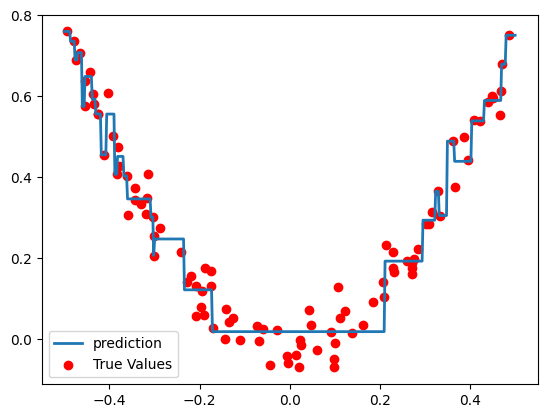

4


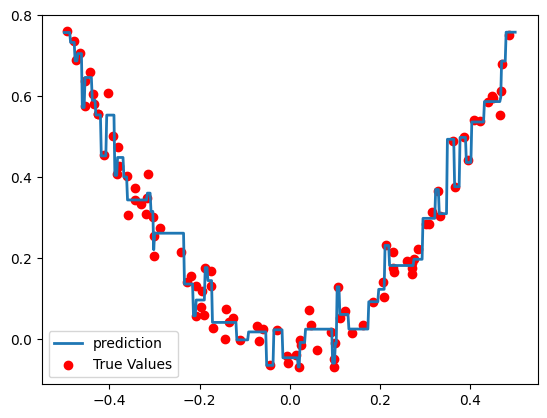

3


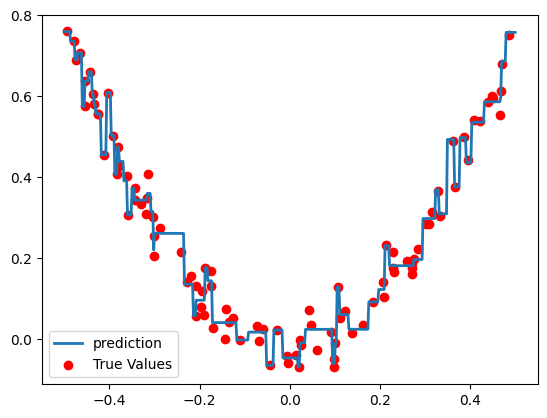

2


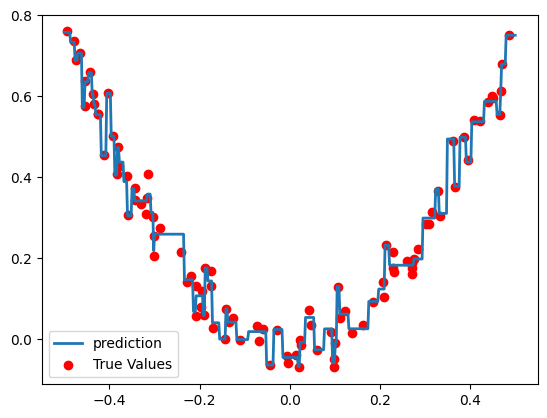

1


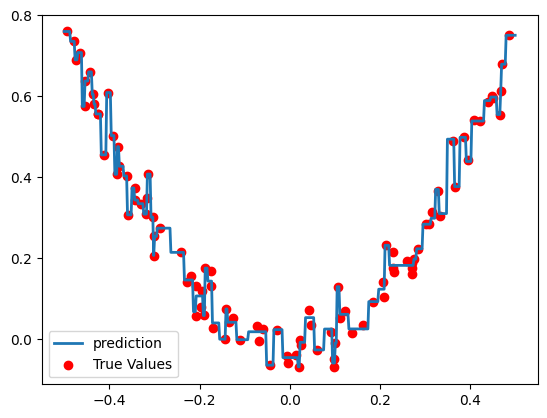

In [62]:
np.random.seed(42)
x=np.random.rand(100,1)-0.5
y=3*x[:,0]**2 +0.05 * np.random.randn(100)
gradient_boost(x,y,number=5,lr=1)